**Filtering and Downsampling** <br>
This notebook performs the filtering (high, low, notch) of the EEG data as well as downsampling to 250 Hz.

In [57]:
# 1. Imports
import numpy as np
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import os

# 2. Configuration
bids_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
sub_number = "14"
task = "loc"
suffix = "eeg"

# 3. Define Output Filenames
# We save the downsampled file to avoid re-processing every time
deriv_root = bids_root  / f"sub-{sub_number}" / "eeg"

# Output 1: Filtered, downsampled EEG File
fname_filtered_downsampled = deriv_root / f"sub-{sub_number}_task-{task}_desc-filtResamp250_eeg.fif"
# Output 2: Annotations CSV
fname_annots = deriv_root / f"sub-{sub_number}_task-{task}_desc-annotations.csv"

print(f"Working on Subject: {sub_number}")
print(f"Downsampled file path: {fname_filtered_downsampled}")

Working on Subject: 14
Downsampled file path: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-filtResamp250_eeg.fif


In [58]:
# Check if filtered, downsampled file already exists
if fname_filtered_downsampled.exists():
    print("Found existing filtered, downsampled file. Loading...")
    raw_eeg = mne.io.read_raw_fif(fname_filtered_downsampled, preload=True)
    print(raw_eeg.info)
else:
    print("No filtered, downsampled file found. Loading from BIDS and processing...")
    # 1. Define BIDS Path
    bids_path = BIDSPath(
        root=bids_root, 
        subject=sub_number, 
        task=task, 
        datatype="eeg", 
        suffix=suffix
    )

    # 2. Load Raw
    raw_eeg, bids_event_id = read_raw_bids(
        bids_path=bids_path, 
        return_event_dict=True,  # <--- HIER: Extrahiert das Mapping direkt aus BIDS
        verbose=False
    )
    # 3. Load events
    events, event_id = mne.events_from_annotations(
        raw_eeg, 
        event_id=bids_event_id,  # <--- Überschreibt den "auto" Parser
        verbose=False
    )

No filtered, downsampled file found. Loading from BIDS and processing...


C:\Users\noahm\AppData\Local\Temp\ipykernel_6052\3422263816.py:18: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['HEOG', 'VEOG']
  raw_eeg, bids_event_id = read_raw_bids(
C:\Users\noahm\AppData\Local\Temp\ipykernel_6052\3422263816.py:18: RuntimeWarning: Not setting positions of 2 eog channels found in montage:
['HEOG', 'VEOG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw_eeg, bids_event_id = read_raw_bids(


I selected those filter settings because ...

In [59]:
# Filtering
raw_filt = raw_eeg.copy().load_data().filter(l_freq=0.5, h_freq=50.0)

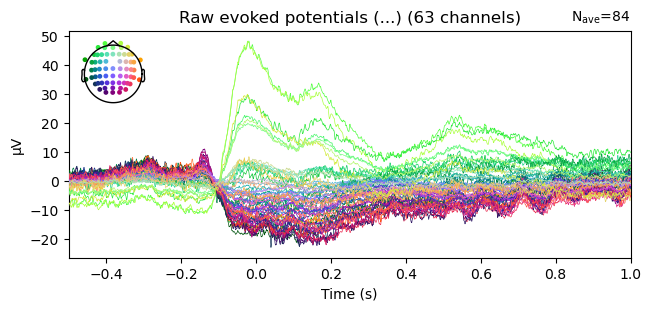

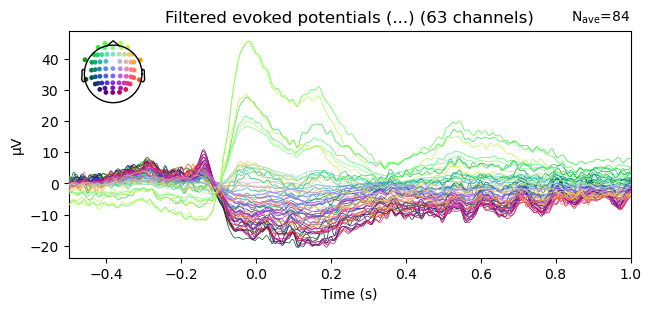

In [60]:
# Have a look at the Evoked potential during experimental event (here retrieval fixation cross) to check if the filtering has worked
events, event_dict = mne.events_from_annotations(raw_eeg)
epochs = mne.Epochs(
    raw_eeg,
    events,
    event_id=event_dict,
    tmin=-0.5,
    tmax=1,
    reject_by_annotation=True, # default parameter
)['ret_fixation'].average().plot(titles = "Raw evoked potentials (...)")

# Have a look at the Evoked potential during experimental event (here Encoding) to check if the filtering has worked
events, event_dict = mne.events_from_annotations(raw_filt)
epochs = mne.Epochs(
    raw_filt,
    events,
    event_id=event_dict,
    tmin=-0.5,
    tmax=1,
    reject_by_annotation=True, # default parameter
)['ret_fixation'].average().plot(titles = "Filtered evoked potentials (...)")

c:\Users\noahm\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\noahm\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


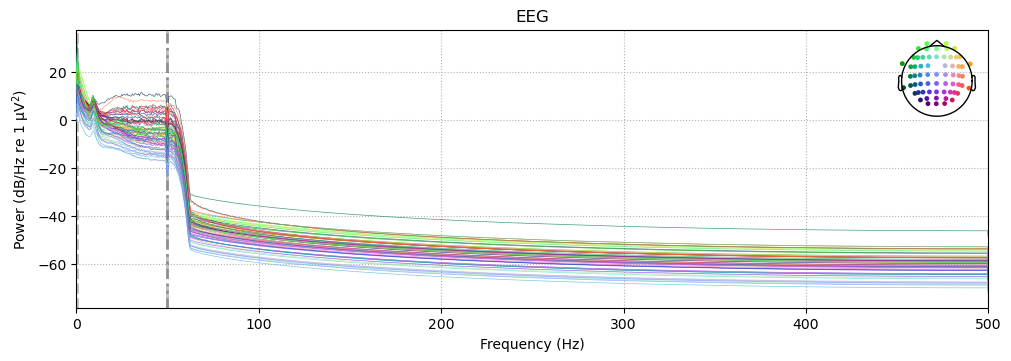

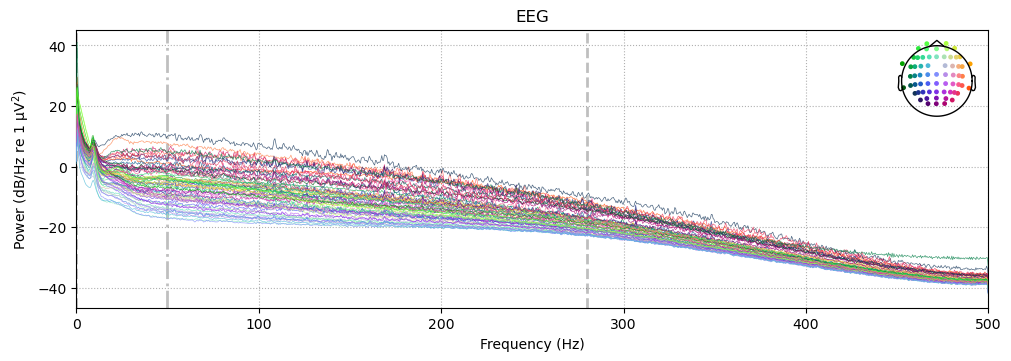

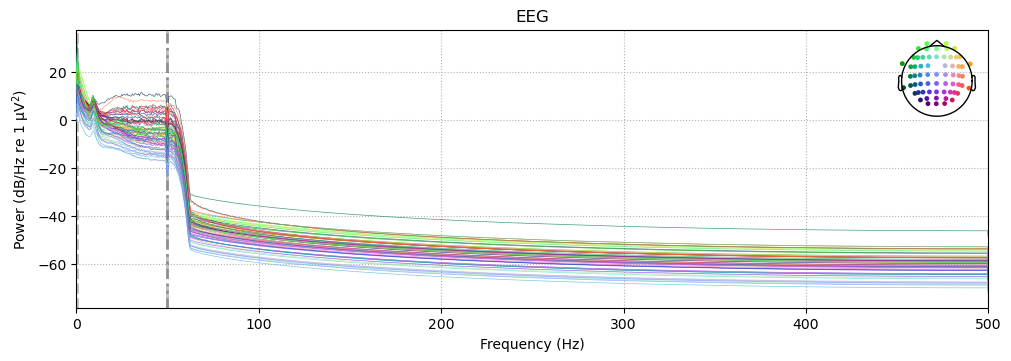

In [61]:
# Apply notch filter for 50 Hz line noise (Europe)
raw_filt.notch_filter(freqs=50, verbose=False)
raw_eeg.plot_psd()
raw_filt.plot_psd()

In [62]:
# Downsampling
raw_filt_downsamp = raw_filt.resample(250)


In [63]:
# Check whether raw_filt_downsamp contains all previous preprocessing steps
keys = ["sfreq", "highpass", "lowpass", "line_freq"]
for key in keys:
    print(f"{key}: {raw_filt_downsamp.info[key]}")


sfreq: 250.0
highpass: 0.5
lowpass: 50.0
line_freq: 50.0


In [64]:
# Save filtered, downsampled data into the derivatives folder
deriv_root.mkdir(parents=True, exist_ok=True)
raw_filt_downsamp.save(fname_filtered_downsampled, overwrite=True)
print(f"Die Datei wurde erfolgreich gespeichert unter: {fname_filtered_downsampled}")

Die Datei wurde erfolgreich gespeichert unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-filtResamp250_eeg.fif
